# Resolución de MKP usando PSO


## Carga de Archivos

Importación de librerías a usar

In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.linear_model import LinearRegression

Bajada de archivos de MKP, se puede cambiar la URL mediante parámetro.


In [2]:
import requests

url = "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb1.txt" # @param ["http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknap1.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb1.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb1.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb2.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb3.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb4.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb5.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb6.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb7.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb8.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb9.txt"] {allow-input: true}

try:
    response = requests.get(url)
    response.raise_for_status()  # Verifica si la solicitud fue exitosa
    text_content = response.text

    # Ahora, text_content contiene el texto del archivo en la URL
    print("Instancia cargada con éxito.")

    # Puedes imprimir o hacer lo que necesites con el texto

except requests.exceptions.RequestException as e:
    print(f"Error al obtener el contenido desde la URL: {e}")


Instancia cargada con éxito.


Función que parsea la url para extraer en una lista las instancias del mkp presentes en el archivo

In [3]:
def cargar_instancia_mkp(cadena):
  # Lista de instancias del problema
  instancias = []


  # Dividir la cadena en líneas y luego en números
  lineas = cadena.strip().split('\n')
  numeros = [list(map(float, linea.split())) for linea in lineas]

  #Lector de archivo
  linea_actual = 0

  # Extraer la cantidad de instancias que contiene el archivo
  n_instancias = int(numeros[linea_actual][0])


  for _ in range(n_instancias):

    # Esto es para que se salte la linea vacía que hay entre instancias
    linea_actual += 1
    if numeros[linea_actual] == [] :
      linea_actual += 1

    # Extraer n, m, y el valor de la solución óptima
    n, m, valor_optimo = numeros[linea_actual]
    n, m = [int(n), int(m)]

    linea_actual += 1

    p = []

    while (len(p)<n):
      p += numeros[linea_actual]
      linea_actual += 1

    # Inicializar una lista vacía para las restricciones y los lados derechos
    r = []
    b = []

    # Extraer los coeficientes de las restricciones r(i,j) y b(i)
    for i in range(m):
      new_restriction = []
      while(len(new_restriction) < n):
        new_restriction = new_restriction + numeros[linea_actual]
        linea_actual += 1
      r.append(new_restriction)  # Agregar la nueva lista a r

    while (len(b) < m):
      b += numeros[linea_actual]
      linea_actual += 1
    linea_actual -= 1

    p = np.array(p)
    r = np.array(r)
    b = np.array(b)

    instancias.append({"n": n, "m": m, "valor_optimo": valor_optimo, "p": p, "r": r, "b": b})

  return instancias

instancias = cargar_instancia_mkp(text_content)

data = random.choice(instancias)



In [4]:
data = instancias[9]

In [5]:
data

{'n': 100,
 'm': 5,
 'valor_optimo': 0.0,
 'p': array([ 720.,  569.,  832.,  746.,  601.,  863.,  596., 1013.,  736.,
         737., 1062.,  381., 1044.,  605.,  970., 1177.,  747.,  842.,
         875.,  627.,  839.,  674.,  897.,  876.,  597.,  649., 1087.,
         752.,  525.,  754.,  692.,  835.,  436., 1183.,  369.,  940.,
         654., 1090.,  780., 1045.,  578.,  896., 1008.,  798.,  734.,
         987.,  694.,  565.,  809.,  818.,  972.,  887.,  614.,  930.,
         694.,  872.,  712.,  500.,  739.,  831.,  522., 1008.,  834.,
         734.,  490.,  924.,  422.,  598.,  499.,  846.,  939.,  797.,
         538.,  656.,  931.,  861.,  784.,  586.,  859.,  620., 1055.,
         645.,  857.,  623.,  797.,  643.,  566.,  811.,  819.,  688.,
         922., 1142.,  902.,  795.,  744.,  754.,  453.,  427.,  839.,
         928.]),
 'r': array([[921., 367., 638., 810., 166., 650., 365., 974., 685., 545., 962.,
         439.,  12., 618., 255., 835., 790., 963., 111., 200., 999., 117.,


In [6]:
n = data['n']  # Número de elementos
m = data['m']  # Número de mochilas
valor_optimo = data['valor_optimo']  # Valor óptimo conocido
p = data['p']  # Coeficientes de valor de los elementos
r = data['r']  # Restricciones de capacidad de las mochilas
b = data['b']  # Lado derecho de las restricciones

density_per_bag = [p / r[i] for i in range(m)]

density_per_bag = np.array(density_per_bag)

# Encontrar el valor máximo entre los elementos finitos
finite_max = np.max(density_per_bag[np.isfinite(density_per_bag)])

# Reemplazar los valores infinitos con el valor máximo encontrado * 10
density_per_bag[np.isinf(density_per_bag)] = finite_max * 10

density = np.min(density_per_bag, axis=0)

# Obtener los índices en orden ascendente
indices_ascendentes = np.argsort(density)

# Función de reparación modificada para usar índices y orden precalculados
def reparar_solucion(solucion, p, r, b, density):
  for i in range(len(solucion)):
    aux = solucion.copy()
    aux[int(indices_ascendentes[i])] = 0
    if not np.all(np.dot(aux, r.T) <= b):
      solucion = aux
    else:
      solucion = aux
      break

  for i in range(len(solucion)):
    aux = solucion.copy()
    aux[int(indices_ascendentes[i])] = 1
    if np.all(np.dot(aux, r.T) <= b):
      solucion = aux
    else:
      break

  valor_total = np.sum(solucion * p)
  return solucion, valor_total

In [7]:
print(n,m,p,r,b, valor_optimo)

100 5 [ 720.  569.  832.  746.  601.  863.  596. 1013.  736.  737. 1062.  381.
 1044.  605.  970. 1177.  747.  842.  875.  627.  839.  674.  897.  876.
  597.  649. 1087.  752.  525.  754.  692.  835.  436. 1183.  369.  940.
  654. 1090.  780. 1045.  578.  896. 1008.  798.  734.  987.  694.  565.
  809.  818.  972.  887.  614.  930.  694.  872.  712.  500.  739.  831.
  522. 1008.  834.  734.  490.  924.  422.  598.  499.  846.  939.  797.
  538.  656.  931.  861.  784.  586.  859.  620. 1055.  645.  857.  623.
  797.  643.  566.  811.  819.  688.  922. 1142.  902.  795.  744.  754.
  453.  427.  839.  928.] [[921. 367. 638. 810. 166. 650. 365. 974. 685. 545. 962. 439.  12. 618.
  255. 835. 790. 963. 111. 200. 999. 117. 615. 718. 297. 399. 998. 579.
  337. 977. 828. 332. 769. 743. 595. 452.  12. 577. 128. 535.  60. 973.
  808. 763. 915. 492. 578. 699. 171. 796. 393. 562. 798. 515.  22. 282.
  549. 430. 639. 802. 145. 348. 865. 377. 658. 663.  95. 341.   3. 508.
  912. 786. 946.  62. 59

# DTW

In [8]:
%%writefile dtw_stagnation.py
from __future__ import annotations
from dataclasses import dataclass, field
from typing import List, Dict, Optional
import numpy as np

def dtw_distance(s: np.ndarray, t: np.ndarray, window: Optional[int] = None) -> float:
    s = np.asarray(s, dtype=float); t = np.asarray(t, dtype=float)
    n, m = len(s), len(t)
    if window is None: window = max(n, m)
    window = max(window, abs(n - m))
    INF = float('inf')
    D = np.full((n + 1, m + 1), INF); D[0, 0] = 0.0
    for i in range(1, n + 1):
        j_start = max(1, i - window); j_end = min(m, i + window); si = s[i-1]
        for j in range(j_start, j_end + 1):
            cost = abs(si - t[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return float(D[n, m])

def first_diff(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float); return np.diff(x, prepend=x[0])

def ddtw_distance(s: np.ndarray, t: np.ndarray, window: Optional[int] = None) -> float:
    return dtw_distance(first_diff(s), first_diff(t), window=window)

def ramp_baseline(start_value: float, s_min: float, length: int) -> np.ndarray:
    i = np.arange(length, dtype=float); return start_value + s_min * i

def constant_baseline(start_value: float, length: int) -> np.ndarray:
    return np.full(length, float(start_value))

def moving_percentile(buffer: List[float], p: float) -> float:
    arr = np.asarray(buffer, dtype=float)
    return float(np.percentile(arr, p)) if arr.size > 0 else float('nan')

@dataclass
class StagnationConfig:
    window: int = 30
    band: int = 0            # si 0 -> 10% de window
    min_slope: float = 0.0
    plateau_max: int = 15
    patience: int = 3
    use_ddtw: bool = False
    adapt_thresholds: bool = True
    p_low: float = 30.0
    p_high: float = 70.0
    def __post_init__(self):
        if self.band <= 0: self.band = max(1, int(0.1 * self.window))

@dataclass
class StagnationMonitor:
    cfg: StagnationConfig
    best_so_far: List[float] = field(default_factory=list)
    no_improve_len: int = 0
    trigger_streak: int = 0
    d1_hist: List[float] = field(default_factory=list)
    d2_hist: List[float] = field(default_factory=list)
    delta_hist: List[float] = field(default_factory=list)

    def update(self, new_best: float):
            # --- Sanitize: convertir a escalar float ---
        if isinstance(new_best, (list, tuple, np.ndarray)):
            arr = np.asarray(new_best, dtype=float)
            # política: usamos el máximo porque el best-so-far es de maximización
            new_best = float(np.max(arr))
        else:
            new_best = float(new_best)

        # si por error se guardó algo no escalar antes, lo reparamos
        if self.best_so_far and isinstance(self.best_so_far[-1], (list, tuple, np.ndarray)):
            self.best_so_far = [float(np.max(np.asarray(v, dtype=float))) for v in self.best_so_far]

        if self.best_so_far and new_best <= self.best_so_far[-1]:
            self.no_improve_len += 1; new_best = self.best_so_far[-1]
        else:
            self.no_improve_len = 0
        self.best_so_far.append(float(new_best))

        n = len(self.best_so_far); W = self.cfg.window
        if n < W:
            return {'ready': False, 'fire': False, 'no_improve_len': self.no_improve_len, 'n': n}

        X = np.array(self.best_so_far[-W:], dtype=float)
        start = X[0]

        s_min = self.cfg.min_slope
        if s_min == 0.0:
            rng = max(1.0, abs(X[-1] - X[0])); s_min = 0.01 * rng / W

        r = ramp_baseline(start, s_min, W); c = constant_baseline(start, W)

        if self.cfg.use_ddtw:
            D1 = ddtw_distance(X, r, window=self.cfg.band); D2 = ddtw_distance(X, c, window=self.cfg.band)
        else:
            D1 = dtw_distance(X, r, window=self.cfg.band); D2 = dtw_distance(X, c, window=self.cfg.band)

        delta = D1 - D2
        self.d1_hist.append(D1); self.d2_hist.append(D2); self.delta_hist.append(delta)

        if self.cfg.adapt_thresholds and len(self.d1_hist) >= 10:
            H_LEN = 100
            theta_c = moving_percentile(self.d2_hist[-H_LEN:], self.cfg.p_low)
            theta_r = moving_percentile(self.d1_hist[-H_LEN:], self.cfg.p_high)
            theta_delta = moving_percentile(self.delta_hist[-H_LEN:], self.cfg.p_high)
        else:
            theta_c = 0.1 * W; theta_r = 0.5 * W; theta_delta = 0.3 * W

        cond_plateau = (self.no_improve_len >= self.cfg.plateau_max)
        cond_constant = (D2 <= theta_c)
        cond_ramp = (D1 >= theta_r) or (delta >= theta_delta)

        if cond_plateau and cond_constant and cond_ramp:
            self.trigger_streak += 1
        else:
            self.trigger_streak = 0

        fire = self.trigger_streak >= self.cfg.patience
        return {'ready': True, 'fire': bool(fire),
                'D1_vs_ramp': float(D1), 'D2_vs_const': float(D2), 'delta': float(delta),
                'theta_c': float(theta_c), 'theta_r': float(theta_r), 'theta_delta': float(theta_delta),
                'no_improve_len': int(self.no_improve_len), 'trigger_streak': int(self.trigger_streak), 'n': int(n)}


Writing dtw_stagnation.py


In [9]:
from dtw_stagnation import StagnationMonitor, StagnationConfig

best = [0,2,2,2,3,3,8,8,8,8,10,10,10,11,11,11,11,11,12]
mon = StagnationMonitor(StagnationConfig(window=10, plateau_max=4, patience=2))
for t,v in enumerate(best,1):
    out = mon.update(v)
    if out.get('ready'):
        print(f"t={t:02d} fire={out['fire']} no_improve={out['no_improve_len']}"
              f" D1={out['D1_vs_ramp']:.1f} D2={out['D2_vs_const']:.1f} Δ={out['delta']:.1f}, theta={out['theta_delta']:.1f} ")


t=10 fire=False no_improve=3 D1=43.6 D2=44.0 Δ=-0.4, theta=3.0 
t=11 fire=False no_improve=0 D1=33.7 D2=34.0 Δ=-0.3, theta=3.0 
t=12 fire=False no_improve=1 D1=41.6 D2=42.0 Δ=-0.4, theta=3.0 
t=13 fire=False no_improve=2 D1=49.6 D2=50.0 Δ=-0.4, theta=3.0 
t=14 fire=False no_improve=0 D1=48.6 D2=49.0 Δ=-0.4, theta=3.0 
t=15 fire=False no_improve=1 D1=56.6 D2=57.0 Δ=-0.4, theta=3.0 
t=16 fire=False no_improve=2 D1=14.9 D2=15.0 Δ=-0.1, theta=3.0 
t=17 fire=False no_improve=3 D1=17.9 D2=18.0 Δ=-0.1, theta=3.0 
t=18 fire=False no_improve=4 D1=20.9 D2=21.0 Δ=-0.1, theta=3.0 
t=19 fire=False no_improve=0 D1=24.8 D2=25.0 Δ=-0.2, theta=-0.2 


# Parametros binarizacion 

In [10]:
# Parámetros del PSO
num_particulas = 20
num_iteraciones = 100
inercia = (0.9 + 0.4)/2
coeficiente_cognitivo = 2
coeficiente_social = 2
epoch = 10

In [11]:
# Parámetros de binarización
V_max = 8

G1_i = 0.5
G1_f = 1

G2_i = 0.5
G2_f = 0.9*V_max

G3_i = 0.5
G3_f = 0

In [12]:
results_original = []
results_version1 = []
results_version2 = []
results_version3 = []
results_version4 = []
results_version5 = []
results_version6 = []
results_version7 = []
results_version8 = []

# Original

Comienzo Epoch 1
iter=019 n=20 D1=829.000 D2=799.000 Δ=30.000 theta=6.0 θc=2.00 θr=10.00 no_improve=9 fire=False best=22332.0
iter=020 n=21 D1=829.000 D2=799.000 Δ=30.000 theta=6.0 θc=2.00 θr=10.00 no_improve=10 fire=False best=22332.0
iter=021 n=22 D1=829.000 D2=799.000 Δ=30.000 theta=6.0 θc=2.00 θr=10.00 no_improve=11 fire=False best=22332.0
iter=022 n=23 D1=829.000 D2=799.000 Δ=30.000 theta=6.0 θc=2.00 θr=10.00 no_improve=12 fire=False best=22332.0
iter=023 n=24 D1=193.000 D2=159.000 Δ=34.000 theta=6.0 θc=2.00 θr=10.00 no_improve=13 fire=False best=22332.0
iter=024 n=25 D1=193.000 D2=159.000 Δ=34.000 theta=6.0 θc=2.00 θr=10.00 no_improve=14 fire=False best=22332.0
iter=025 n=26 D1=193.000 D2=159.000 Δ=34.000 theta=6.0 θc=2.00 θr=10.00 no_improve=15 fire=False best=22332.0
iter=026 n=27 D1=193.000 D2=159.000 Δ=34.000 theta=6.0 θc=2.00 θr=10.00 no_improve=16 fire=False best=22332.0
iter=027 n=28 D1=193.000 D2=159.000 Δ=34.000 theta=6.0 θc=2.00 θr=10.00 no_improve=17 fire=False best=22

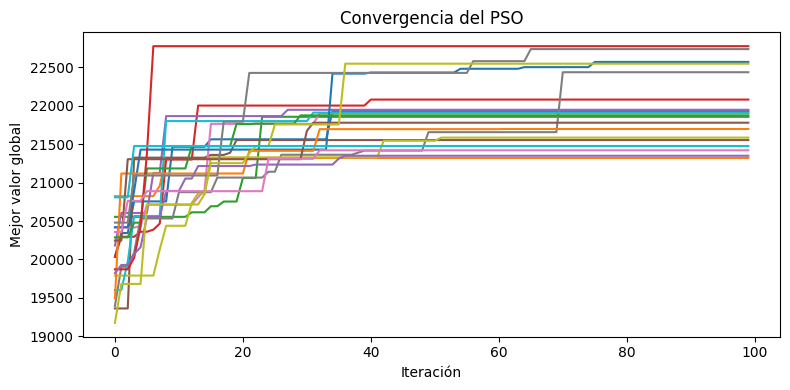

In [13]:
from dtw_stagnation import StagnationMonitor, StagnationConfig

#original
for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")

  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=True  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)


    for particula in particulas:
      # Actualizar velocidad y posición de la partícula
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      L1 = -G1 * nueva_solucion / (V_max - G2 ) + G3
      L2 = G1 * nueva_solucion / (V_max - G2 ) + G3

      L1 = np.clip(L1,0,1)
      L2 = np.clip(L2,0,1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()

      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness


      # Actualizar la mejor solución personal
      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      # Actualizar el mejor global
      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']


    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    #mio
    historial_mejor_global2.append(mejor_valor_global)
    out = mon.update(mejor_valor_global)

    if out.get("ready"):
      print(
          f"iter={iteracion:03d}",
          f"n={out['n']}",
          f"D1={out['D1_vs_ramp']:.3f}",
          f"D2={out['D2_vs_const']:.3f}",
          f"Δ={out['delta']:.3f}",
          f"theta={out['theta_delta']}",
          f"θc={out['theta_c']:.2f}",
          f"θr={out['theta_r']:.2f}",
          f"no_improve={out['no_improve_len']}",
          f"fire={out['fire']}",
          f"best={mejor_valor_global:.1f}",

      )

  results_original.append(mejor_valor_global)
  print(f"Fin Epoch {aux + 1}")

print(results_original)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()

# Versiones

### Versión (original) Autoadaptativa (4 Estados DTW)
Modulación continua de parámetros en base a $\Delta = D_1 - D_2$.

Comienzo Epoch 1
i=019 | Estado: Explorar mucho  | Δ=  26.0 | θδ=   6.0 | d1=1099.0 d2=1073.0 best=22290.0
i=020 | Estado: Explorar mucho  | Δ=  30.0 | θδ=   6.0 | d1=616.0 d2=586.0 best=22382.0
i=021 | Estado: Explorar mucho  | Δ=  26.0 | θδ=   6.0 | d1=704.0 d2=678.0 best=22643.0
i=022 | Estado: Explorar mucho  | Δ=  22.0 | θδ=   6.0 | d1=961.0 d2=939.0 best=22643.0
i=023 | Estado: Explorar mucho  | Δ=  22.0 | θδ=   6.0 | d1=961.0 d2=939.0 best=22643.0
i=024 | Estado: Explorar mucho  | Δ=  22.0 | θδ=   6.0 | d1=961.0 d2=939.0 best=22643.0
i=025 | Estado: Explorar mucho  | Δ=  22.0 | θδ=   6.0 | d1=961.0 d2=939.0 best=22643.0
i=026 | Estado: Explorar mucho  | Δ=  22.0 | θδ=   6.0 | d1=961.0 d2=939.0 best=22643.0
i=027 | Estado: Explorar mucho  | Δ=  22.0 | θδ=   6.0 | d1=961.0 d2=939.0 best=22643.0
i=028 | Estado: Explorar poco   | Δ=  26.0 | θδ=  26.0 | d1=441.0 d2=415.0 best=22643.0
i=029 | Estado: Explorar poco   | Δ=  26.0 | θδ=  26.0 | d1=441.0 d2=415.0 best=22643.0
i=030 | Estad

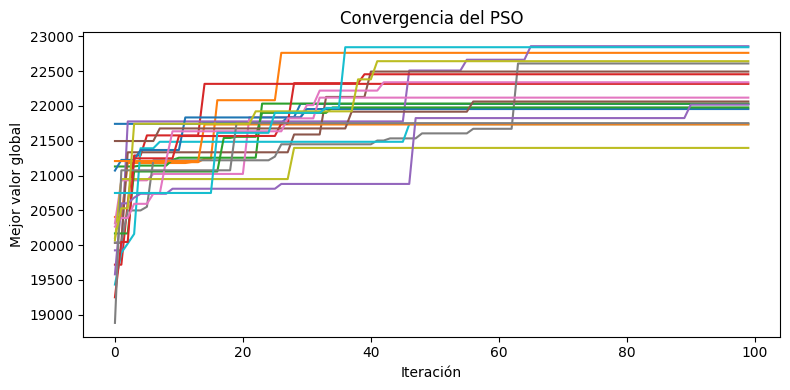

In [ ]:
from dtw_stagnation import StagnationMonitor, StagnationConfig
results_autoadaptativa = []

# Versión Autoadaptativa (4 Estados DTW)
for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")

  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=False  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    # --- 1. DTW y Autoadaptación ---
    inercia = 0.65
    coeficiente_cognitivo = 2.0
    coeficiente_social = 2.0
    estado_actual = "Warm-up"
    
    out = mon.update(mejor_valor_global)

    if out.get("ready"):
        delta = out["delta"]
        theta_delta = out["theta_delta"]
        
        if delta > theta_delta:
            estado_actual = "Explorar mucho"
            inercia = 0.9; coeficiente_cognitivo = 2.5; coeficiente_social = 0.5
        elif 0 <= delta <= theta_delta:
            estado_actual = "Explorar poco"
            inercia = 0.75; coeficiente_cognitivo = 2.2; coeficiente_social = 1.0
        elif -theta_delta <= delta < 0:
            estado_actual = "Explotar poco"
            inercia = 0.65; coeficiente_cognitivo = 2.0; coeficiente_social = 2.0
        else:
            estado_actual = "Explotar mucho"
            inercia = 0.4; coeficiente_cognitivo = 1.0; coeficiente_social = 2.8

    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)

    for particula in particulas:
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      L1 = -G1 * nueva_solucion / (V_max - G2 ) + G3
      L2 = G1 * nueva_solucion / (V_max - G2 ) + G3

      L1 = np.clip(L1,0,1)
      L2 = np.clip(L2,0,1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()

      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness

      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']

    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    historial_mejor_global2.append(mejor_valor_global)

    if out.get("ready"):
      print(
          f"i={iteracion:03d} |",
          f"Estado: {estado_actual:<15} |",
          f"Δ={out['delta']:6.1f} |",
          f"θδ={out['theta_delta']:6.1f} |",
          f"d1={out['D1_vs_ramp']}",
          f"d2={out['D2_vs_const']}",
          #f"w={inercia:.2f} c1={coeficiente_cognitivo:.1f} c2={coeficiente_social:.1f} |",
          f"best={mejor_valor_global:.1f}"
      )

  results_autoadaptativa.append(mejor_valor_global)
  print(f"Fin Epoch {aux + 1}")

print(results_autoadaptativa)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()

### Version 1 (Intensificación Adaptativa )

Comienzo Epoch 1
i=009 | Estado: Warm-up         | Δ=  34.0 | θδ=   6.0 | d1=463.0| d2=429.0| best=21965.0
i=010 | Estado: Explorar mucho  | Δ=  34.0 | θδ=   6.0 | d1=463.0| d2=429.0| best=21965.0
i=011 | Estado: Explorar mucho  | Δ=  34.0 | θδ=   6.0 | d1=463.0| d2=429.0| best=21965.0
i=012 | Estado: Explorar mucho  | Δ=  34.0 | θδ=   6.0 | d1=463.0| d2=429.0| best=21965.0
--- FASE DE INTENSIFICACIÓN en iter 12 ---
i=013 | Estado: Explorar mucho  | Δ=  34.0 | θδ=   6.0 | d1=463.0| d2=429.0| best=21965.0
--- FASE DE INTENSIFICACIÓN en iter 13 ---
i=014 | Estado: Explorar mucho  | Δ=  30.0 | θδ=  34.0 | d1=32.0| d2=2.0| best=21967.0
i=015 | Estado: Explorar poco   | Δ=  26.0 | θδ=  34.0 | d1=163.0| d2=137.0| best=22102.0
i=016 | Estado: Explorar poco   | Δ=  26.0 | θδ=  34.0 | d1=163.0| d2=137.0| best=22102.0
i=017 | Estado: Explorar poco   | Δ=  26.0 | θδ=  34.0 | d1=163.0| d2=137.0| best=22102.0
i=018 | Estado: Explorar poco   | Δ=  26.0 | θδ=  34.0 | d1=163.0| d2=137.0| best=22102.0


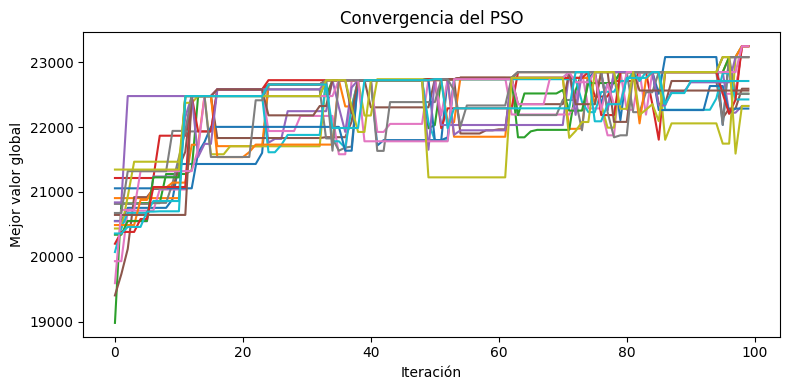

In [17]:
for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")

  from dtw_stagnation import StagnationMonitor, StagnationConfig
  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=True  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Parámetros Base (Explotación)
  W_BASE = (0.9 + 0.4) / 2
  C1_BASE = 2
  C2_BASE = 2

  

  # Estado actual de los parámetros
  inercia = W_BASE
  coeficiente_cognitivo = C1_BASE
  coeficiente_social = C2_BASE

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    # --- 1. DTW y Autoadaptación ---
    
    inercia = 0.65
    coeficiente_cognitivo = 2.0
    coeficiente_social = 2.0
    estado_actual = "Warm-up"

    out = mon.update(mejor_valor_global)
    if out.get("ready"):
        delta = out["delta"]
        theta_delta = out["theta_delta"]
        
        if delta > theta_delta:
            estado_actual = "Explorar mucho"
            inercia = 0.9; coeficiente_cognitivo = 2.5; coeficiente_social = 0.5
        elif 0 <= delta <= theta_delta:
            estado_actual = "Explorar poco"
            inercia = 0.75; coeficiente_cognitivo = 2.2; coeficiente_social = 1.0
        elif -theta_delta <= delta < 0:
            estado_actual = "Explotar poco"
            inercia = 0.65; coeficiente_cognitivo = 2.0; coeficiente_social = 2.0
        else:
            estado_actual = "Explotar mucho"
            inercia = 0.4; coeficiente_cognitivo = 1.0; coeficiente_social = 2.8

    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)


    for particula in particulas:
      # Actualizar velocidad y posición de la partícula
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      L1 = -G1 * nueva_solucion / (V_max - G2 ) + G3
      L2 = G1 * nueva_solucion / (V_max - G2 ) + G3

      L1 = np.clip(L1,0,1)
      L2 = np.clip(L2,0,1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()

      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness


      # Actualizar la mejor solución personal
      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      # Actualizar el mejor global
      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']


    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    #mio
    historial_mejor_global2.append(mejor_valor_global)
    out = mon.update(mejor_valor_global)

    if out.get("ready"):
      print(
          f"i={iteracion:03d} |",
          f"Estado: {estado_actual:<15} |",
          f"Δ={out['delta']:6.1f} |",
          f"θδ={out['theta_delta']:6.1f} |",
          f"d1={out['D1_vs_ramp']}|",
          f"d2={out['D2_vs_const']}|",
          #f"w={inercia:.2f} c1={coeficiente_cognitivo:.1f} c2={coeficiente_social:.1f} |",
          f"best={mejor_valor_global:.1f}"
      )

      '''
      Se activa medidas para el estancamiento cuando cumple:
      1-Cuando fire = True (Detecta estancamiento)
      2-LLeva 15 iteraciones sin mejorar (no_improve_len)
      '''
      if out["fire"] or out["no_improve_len"] >= 15:
        print(f"--- FASE DE INTENSIFICACIÓN en iter {iteracion} ---")

        '''
        Busqueda local en la vecindad del mejor global actual
        '''
        for _ in range(50):
          vecino = mejor_solucion_global.copy()

          '''
          Se realiza el swap de 2 bits aleatorios dentro de la solucion actual
          esto en busca de combinaciones mejores dentro de la misma zona.
          '''
          idx_i, idx_j = random.sample(range(n), 2)
          vecino[idx_i] ^= 1
          vecino[idx_j] ^= 1

          '''
          Se repara la solucion emergente para que cumpla con las restricciones del
          problema.
          '''
          vecino, val_vecino = reparar_solucion(vecino, p, r, b, indices_ascendentes)

          '''
          En caso de encontrar una solucion mejor, se actualiza el mejor global.
          '''
          if val_vecino > mejor_valor_global:
            mejor_valor_global = val_vecino
            mejor_solucion_global = vecino
            print(f"   ↑ [Intensificación] Nuevo máximo: {mejor_valor_global}")

        '''
        -Se baja la inercia en busca de que las particulas se 'peguen' al mejor
        global.
        -Un coeficiente cognitivo bajo para menor exploracion individual.
        -Un coeficiente social alto para que todas sigan al mejor global.
        '''
        inercia = 0.4
        coeficiente_cognitivo = 1.0
        coeficiente_social = 2.5

        '''
        Se toma el 50% de las particulas y se mueve a la vecindad del mejor global.
        '''
        for p_idx in random.sample(range(num_particulas), num_particulas // 2):

          '''
          Se genera una solucion parecida a la del mejor global con solo 1 bit
          de diferencia.
          '''
          refinado = mejor_solucion_global.copy()
          idx_bit = random.randint(0, n - 1)
          refinado[idx_bit] ^= 1

          '''
          Se repara la solucion emergente para que cumpla con las restricciones del
          problema.
          '''
          refinado, val_refinado = reparar_solucion(refinado, p, r, b, indices_ascendentes)

          '''
          Se actualiza la particula y su memoria personal con la nueva solucion.
          '''
          particulas[p_idx]['solucion'] = refinado
          particulas[p_idx]['valor'] = val_refinado
          particulas[p_idx]['mejor_solucion_personal'] = refinado
          particulas[p_idx]['mejor_valor_personal'] = val_refinado

      elif out["no_improve_len"] == 0:
        '''
        Se restaura los valores estandar de PSO si hay un progreso continuo.
        '''
        inercia = W_BASE
        coeficiente_cognitivo = C1_BASE
        coeficiente_social = C2_BASE

  results_version1.append(mejor_valor_global)

print(results_version1)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()

### Version 2 (Ajuste Cíclico Adaptativo de Parámetros)

In [16]:

from dtw_stagnation import StagnationMonitor, StagnationConfig

for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")
  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=F  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Parámetros Base (Explotación)
  W_BASE = (0.9 + 0.4) / 2
  C1_BASE = 2
  C2_BASE = 2

  # Estado actual de los parámetros
  inercia = W_BASE
  coeficiente_cognitivo = C1_BASE
  coeficiente_social = C2_BASE

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    estado_actual = "Warm-up"

    out = mon.update(mejor_valor_global)

    if out.get("ready"):
        delta = out["delta"]
        theta_delta = out["theta_delta"]
        
        if delta > theta_delta:
            estado_actual = "Explorar mucho"
            inercia = 0.9; coeficiente_cognitivo = 2.5; coeficiente_social = 0.5
        elif 0 <= delta <= theta_delta:
            estado_actual = "Explorar poco"
            inercia = 0.75; coeficiente_cognitivo = 2.2; coeficiente_social = 1.0
        elif -theta_delta <= delta < 0:
            estado_actual = "Explotar poco"
            inercia = 0.65; coeficiente_cognitivo = 2.0; coeficiente_social = 2.0
        else:
            estado_actual = "Explotar mucho"
            inercia = 0.4; coeficiente_cognitivo = 1.0; coeficiente_social = 2.8

    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)


    for particula in particulas:
      # Actualizar velocidad y posición de la partícula
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      L1 = -G1 * nueva_solucion / (V_max - G2 ) + G3
      L2 = G1 * nueva_solucion / (V_max - G2 ) + G3

      L1 = np.clip(L1,0,1)
      L2 = np.clip(L2,0,1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()

      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness


      # Actualizar la mejor solución personal
      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      # Actualizar el mejor global
      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']


    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    #mio
    historial_mejor_global2.append(mejor_valor_global)
    out = mon.update(mejor_valor_global)

    if out.get("ready"):
      print(
          f"i={iteracion:03d} |",
          f"Estado: {estado_actual:<15} |",
          f"Δ={out['delta']:6.1f} |",
          f"θδ={out['theta_delta']:6.1f} |",
          f"d1={out['D1_vs_ramp']}|",
          f"d2={out['D2_vs_const']}|",
          #f"w={inercia:.2f} c1={coeficiente_cognitivo:.1f} c2={coeficiente_social:.1f} |",
          f"best={mejor_valor_global:.1f}"
      )

      '''
      Se activa medidas para el estancamiento cuando cumple:
      1-Cuando fire = True (Detecta estancamiento)
      2-LLeva 15 iteraciones sin mejorar (no_improve_len)
      '''
      if out["fire"] or out["no_improve_len"] >= 15:

        '''
        Ciclo convierte el tiempo sin mejora en una fase que hace oscilar el
        comportamiento del algoritmo, evitando que haga lo mismo al momento de
        estar estancado. (Da como resultado valores entre 0.0 a 0.9)
        '''
        ciclo = (out["no_improve_len"] % 10) / 10.0  # Va de 0.0 a 0.9

        '''
        El enjambre se mueve mas o menos dependiendo del resultado de ciclo.
        '''
        inercia = 0.4 + (0.5 * ciclo)

        '''
        Aumenta la exploracion individual cuando el ciclo avanza.
        '''
        coeficiente_cognitivo = 1.5 + (1.0 * ciclo)

        '''
        -Cuando la inercia es alta, la presion social es baja.
        -Cuando la inercia es baja, la presion social es alta.
        '''
        coeficiente_social = 2.0 - (1.5 * ciclo)

        print(f"--- AJUSTE CÍCLICO (Iter estancada: {out['no_improve_len']}) ---")
        print(f"    w: {inercia:.2f}, c1: {coeficiente_cognitivo:.2f}, c2: {coeficiente_social:.2f}")

      elif out["no_improve_len"] == 0:
        '''
        Se restaura los valores estandar de PSO si hay un progreso continuo.
        '''
        inercia = W_BASE
        coeficiente_cognitivo = C1_BASE
        coeficiente_social = C2_BASE
  results_version2.append(mejor_valor_global)

print(results_version2)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()


Comienzo Epoch 1


NameError: name 'F' is not defined

### Version 3 (Exploración adaptativa)

In [ ]:

from dtw_stagnation import StagnationMonitor, StagnationConfig
for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")
  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=False  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Parámetros Base (Explotación)
  W_BASE = (0.9 + 0.4) / 2
  C1_BASE = 2
  C2_BASE = 2

  # Estado actual de los parámetros
  inercia = W_BASE
  coeficiente_cognitivo = C1_BASE
  coeficiente_social = C2_BASE

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    estado_actual = "Warm-up"
    out = mon.update(mejor_valor_global)
    if out.get("ready"):
        delta = out["delta"]
        theta_delta = out["theta_delta"]
        
        if delta > theta_delta:
            estado_actual = "Explorar mucho"
            inercia = 0.9; coeficiente_cognitivo = 2.5; coeficiente_social = 0.5
        elif 0 <= delta <= theta_delta:
            estado_actual = "Explorar poco"
            inercia = 0.75; coeficiente_cognitivo = 2.2; coeficiente_social = 1.0
        elif -theta_delta <= delta < 0:
            estado_actual = "Explotar poco"
            inercia = 0.65; coeficiente_cognitivo = 2.0; coeficiente_social = 2.0
        else:
            estado_actual = "Explotar mucho"
            inercia = 0.4; coeficiente_cognitivo = 1.0; coeficiente_social = 2.8
    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)


    for particula in particulas:
      # Actualizar velocidad y posición de la partícula
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      L1 = -G1 * nueva_solucion / (V_max - G2 ) + G3
      L2 = G1 * nueva_solucion / (V_max - G2 ) + G3

      L1 = np.clip(L1,0,1)
      L2 = np.clip(L2,0,1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()

      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness


      # Actualizar la mejor solución personal
      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      # Actualizar el mejor global
      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']


    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    #mio
    historial_mejor_global2.append(mejor_valor_global)
    out = mon.update(mejor_valor_global)

    if out.get("ready"):
      print(
          f"i={iteracion:03d} |",
          f"Estado: {estado_actual:<15} |",
          f"Δ={out['delta']:6.1f} |",
          f"θδ={out['theta_delta']:6.1f} |",
          f"d1={out['D1_vs_ramp']}|",
          f"d2={out['D2_vs_const']}|",
          #f"w={inercia:.2f} c1={coeficiente_cognitivo:.1f} c2={coeficiente_social:.1f} |",
          f"best={mejor_valor_global:.1f}"
      )

      '''
      Se activa medidas para el estancamiento cuando cumple:
      1-Cuando fire = True (Detecta estancamiento)
      2-LLeva 15 iteraciones sin mejorar (no_improve_len)
      '''
      if out["fire"] or out["no_improve_len"] >= 15:
        print(f"--- AJUSTE DE PARÁMETROS en iter {iteracion} (Estancamiento: {out['no_improve_len']}) ---")

        '''
        Se aumenta la inercia para permitir a las particulas 'saltar' obstaculos.
        '''
        inercia = min(0.95, inercia * 1.1)

        '''
        Se aumenta el coeficiente cognitivo, fomentando que la particula explore
        basandose en su propio conocimiento, alejandose del grupo.
        '''
        coeficiente_cognitivo = min(2.5, coeficiente_cognitivo * 1.1)

        '''
        Reduccion del coeficiente social para debilitar el mejor global y las
        particulas dejen de colapsar en el punto de estancamiento.
        '''
        coeficiente_social = max(0.4, coeficiente_social * 0.8)

        print(f"   Modo Exploración -> w: {inercia:.2f}, c1: {coeficiente_cognitivo:.2f}, c2: {coeficiente_social:.2f}")

      '''
      Si se encuentra una mejora (no_improve_len vuelve a 0), se restaura los valores originales.
      '''
    elif out["no_improve_len"] == 0:
      '''
      Si inercia == W_BASE ya esta en modo normal en caso contrario modificar
      los parametros.
      '''
      if inercia != W_BASE:
        print(f"+++ MEJORA DETECTADA en iter {iteracion} - Restaurando Parámetros Base +++")
        inercia = W_BASE
        coeficiente_cognitivo = C1_BASE
        coeficiente_social = C2_BASE
  results_version3.append(mejor_valor_global)

print(results_version3)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()


### Version 4 (Ajuste dinámico no lineal)

Comienzo Epoch 1
i=009 | Estado: Warm-up         | Δ=  22.0 | θδ=   6.0 | d1=1802.0| d2=1780.0| best=22092.0
i=010 | Estado: Explorar mucho  | Δ=  26.0 | θδ=   6.0 | d1=920.0| d2=894.0| best=22092.0
i=011 | Estado: Explorar mucho  | Δ=  26.0 | θδ=   6.0 | d1=920.0| d2=894.0| best=22092.0
i=012 | Estado: Explorar mucho  | Δ=  30.0 | θδ=   6.0 | d1=225.0| d2=195.0| best=22092.0
i=013 | Estado: Explorar mucho  | Δ=  34.0 | θδ=   6.0 | d1=205.0| d2=171.0| best=22092.0
i=014 | Estado: Explorar mucho  | Δ=  34.0 | θδ=   6.0 | d1=205.0| d2=171.0| best=22092.0
i=015 | Estado: Explorar mucho  | Δ=  34.0 | θδ=   6.0 | d1=205.0| d2=171.0| best=22092.0
--- AJUSTE DINÁMICO (Iter: 16) ---
    w: 0.457, c1: 1.617, c2: 2.011 (Sev: 1.32)
i=016 | Estado: Explorar mucho  | Δ=  34.0 | θδ=   6.0 | d1=205.0| d2=171.0| best=22092.0
--- AJUSTE DINÁMICO (Iter: 18) ---
    w: 0.559, c1: 1.789, c2: 1.775 (Sev: 1.36)
i=017 | Estado: Explorar mucho  | Δ=  38.0 | θδ=   6.0 | d1=38.0| d2=0.0| best=22092.0
--- AJUSTE

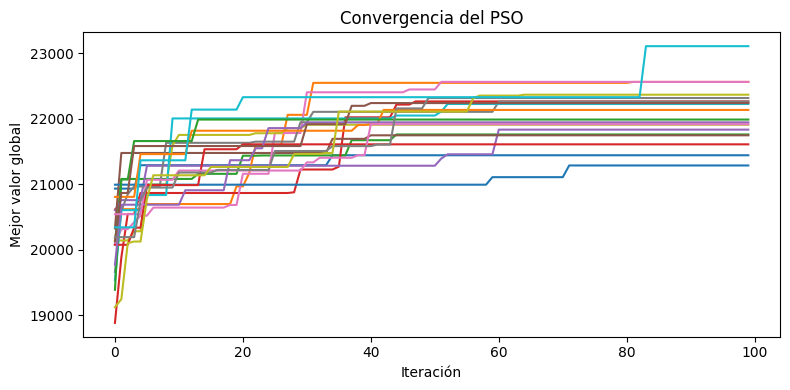

In [ ]:
from dtw_stagnation import StagnationMonitor, StagnationConfig

for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")
  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=False  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Parámetros Base (Explotación)
  W_BASE = (0.9 + 0.4) / 2
  C1_BASE = 2
  C2_BASE = 2

  # Estado actual de los parámetros
  inercia = W_BASE
  coeficiente_cognitivo = C1_BASE
  coeficiente_social = C2_BASE

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    estado_actual = "Warm-up"
    out = mon.update(mejor_valor_global)
    if out.get("ready"):
        delta = out["delta"]
        theta_delta = out["theta_delta"]
        
        if delta > theta_delta:
            estado_actual = "Explorar mucho"
            inercia = 0.9; coeficiente_cognitivo = 2.5; coeficiente_social = 0.5
        elif 0 <= delta <= theta_delta:
            estado_actual = "Explorar poco"
            inercia = 0.75; coeficiente_cognitivo = 2.2; coeficiente_social = 1.0
        elif -theta_delta <= delta < 0:
            estado_actual = "Explotar poco"
            inercia = 0.65; coeficiente_cognitivo = 2.0; coeficiente_social = 2.0
        else:
            estado_actual = "Explotar mucho"
            inercia = 0.4; coeficiente_cognitivo = 1.0; coeficiente_social = 2.8

    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)


    for particula in particulas:
      # Actualizar velocidad y posición de la partícula
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      L1 = -G1 * nueva_solucion / (V_max - G2 ) + G3
      L2 = G1 * nueva_solucion / (V_max - G2 ) + G3

      L1 = np.clip(L1,0,1)
      L2 = np.clip(L2,0,1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()

      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness


      # Actualizar la mejor solución personal
      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      # Actualizar el mejor global
      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']


    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    #mio
    historial_mejor_global2.append(mejor_valor_global)
    out = mon.update(mejor_valor_global)

    if out.get("ready"):
      print(
          f"i={iteracion:03d} |",
          f"Estado: {estado_actual:<15} |",
          f"Δ={out['delta']:6.1f} |",
          f"θδ={out['theta_delta']:6.1f} |",
          f"d1={out['D1_vs_ramp']}|",
          f"d2={out['D2_vs_const']}|",
          #f"w={inercia:.2f} c1={coeficiente_cognitivo:.1f} c2={coeficiente_social:.1f} |",
          f"best={mejor_valor_global:.1f}"
      )

      '''
      Se activa medidas para el estancamiento cuando cumple:
      1-Cuando fire = True (Detecta estancamiento)
      2-LLeva 15 iteraciones sin mejorar (no_improve_len)
      '''
      if out["fire"] or out["no_improve_len"] >= 15:
        '''
        Ciclo crece con el estancamiento total, de modo que hace que cada ciclo sea
        un poco mas fuerte que el anterior.
        '''
        ciclo = min(2.0, 1.0 + (out["no_improve_len"] / 50.0))

        '''
        Ciclo no lineal
        Fase va de 0 a 1, pero de forma curva (crece lento al inicio, rápido al final)
        '''
        fase_lineal = (out["no_improve_len"] % 12) / 12.0
        fase = fase_lineal ** 2

        '''
        Inercia con ruido, evita que el enjambre se mueva exactamente igual en cada intento.
        '''
        ruido = random.uniform(-0.05, 0.05)
        inercia = np.clip(0.4 + (0.5 * fase * ciclo) + ruido, 0.3, 0.95)

        '''
        c1 (Cognitivo) sube para que busquen por su cuenta
        c2 (Social) baja para que ignoren al grupo estancado
        '''
        coeficiente_cognitivo = np.clip(1.5 + (1.2 * fase) + ruido, 1.2, 3.0)
        coeficiente_social = np.clip(2.2 - (1.7 * fase), 0.3, 2.2)

        print(f"--- AJUSTE DINÁMICO (Iter: {out['no_improve_len']}) ---")
        print(f"    w: {inercia:.3f}, c1: {coeficiente_cognitivo:.3f}, c2: {coeficiente_social:.3f} (Sev: {ciclo:.2f})")

      elif out["no_improve_len"] == 0:
        '''
        Regreso a valores base de refinamiento
        '''
        inercia, coeficiente_cognitivo, coeficiente_social = W_BASE, C1_BASE, C2_BASE
  results_version4.append(mejor_valor_global)

print(results_version4)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()

### Version 8 (Ruin & Recreate adaptativo)

Comienzo Epoch 1
i=019 | Estado: Warm-up         | Δ=  18.0 | θδ=   6.0 | d1=896.0| d2=878.0| best=22297.0
i=020 | Estado: Explorar mucho  | Δ=  18.0 | θδ=   6.0 | d1=896.0| d2=878.0| best=22297.0
i=021 | Estado: Explorar mucho  | Δ=  18.0 | θδ=   6.0 | d1=896.0| d2=878.0| best=22297.0
i=022 | Estado: Explorar mucho  | Δ=  18.0 | θδ=   6.0 | d1=896.0| d2=878.0| best=22297.0
i=023 | Estado: Explorar mucho  | Δ=  18.0 | θδ=   6.0 | d1=896.0| d2=878.0| best=22297.0
i=024 | Estado: Explorar mucho  | Δ=  22.0 | θδ=   6.0 | d1=670.0| d2=648.0| best=22297.0
i=025 | Estado: Explorar mucho  | Δ=  22.0 | θδ=   6.0 | d1=670.0| d2=648.0| best=22297.0
i=026 | Estado: Explorar mucho  | Δ=  22.0 | θδ=   6.0 | d1=670.0| d2=648.0| best=22297.0
i=027 | Estado: Explorar mucho  | Δ=  26.0 | θδ=   6.0 | d1=375.0| d2=349.0| best=22297.0
i=028 | Estado: Explorar mucho  | Δ=  26.0 | θδ=  22.0 | d1=375.0| d2=349.0| best=22297.0
--- RUIN & RECREATE en iter 28 ---
   ↑ [R&R] Salto a 23188.0
i=029 | Estado: Explo

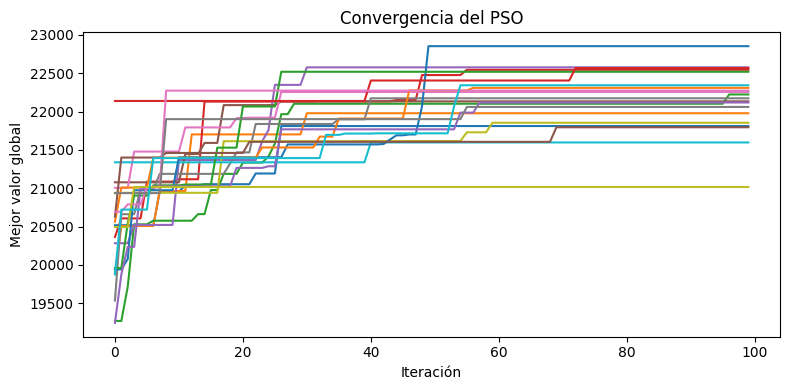

In [ ]:

def calcular_eficiencia(j):
    consumo_normalizado = 0
    for i in range(len(b)):
        consumo_normalizado += r[i][j] / b[i]
    return p[j] / consumo_normalizado
from dtw_stagnation import StagnationMonitor, StagnationConfig

for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")
  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=True  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Parámetros Base (Explotación)
  W_BASE = (0.9 + 0.4) / 2
  C1_BASE = 2
  C2_BASE = 2

  # Estado actual de los parámetros
  inercia = W_BASE
  coeficiente_cognitivo = C1_BASE
  coeficiente_social = C2_BASE

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    estado_actual = "Warm-up"
    
    if out.get("ready"):
        delta = out["delta"]
        theta_delta = out["theta_delta"]
        
        if delta > theta_delta:
            estado_actual = "Explorar mucho"
            inercia = 0.9; coeficiente_cognitivo = 2.5; coeficiente_social = 0.5
        elif 0 <= delta <= theta_delta:
            estado_actual = "Explorar poco"
            inercia = 0.75; coeficiente_cognitivo = 2.2; coeficiente_social = 1.0
        elif -theta_delta <= delta < 0:
            estado_actual = "Explotar poco"
            inercia = 0.65; coeficiente_cognitivo = 2.0; coeficiente_social = 2.0
        else:
            estado_actual = "Explotar mucho"
            inercia = 0.4; coeficiente_cognitivo = 1.0; coeficiente_social = 2.8

    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)


    for particula in particulas:
      # Actualizar velocidad y posición de la partícula
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      alpha = 1.0 - iteracion / num_iteraciones
      # opción más suave (recomendada):
      # alpha = (1.0 - iteracion / num_iteraciones) ** 2

      L1 = (-G1 * nueva_solucion / (V_max - G2 ) + G3) * alpha
      L2 = ( G1 * nueva_solucion / (V_max - G2 ) + G3) * alpha

      L1 = np.clip(L1, 0, 1)
      L2 = np.clip(L2, 0, 1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()


      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness


      # Actualizar la mejor solución personal
      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      # Actualizar el mejor global
      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']


    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    #mio
    historial_mejor_global2.append(mejor_valor_global)
    out = mon.update(mejor_valor_global)

    if out.get("ready"):
      print(
          f"i={iteracion:03d} |",
          f"Estado: {estado_actual:<15} |",
          f"Δ={out['delta']:6.1f} |",
          f"θδ={out['theta_delta']:6.1f} |",
          f"d1={out['D1_vs_ramp']}|",
          f"d2={out['D2_vs_const']}|",
          #f"w={inercia:.2f} c1={coeficiente_cognitivo:.1f} c2={coeficiente_social:.1f} |",
          f"best={mejor_valor_global:.1f}"
      )

      #Se activa en caso de llevar 15 iteraciones sin mejorar el global o DTW
      #concluye que es una meseta
      if out["fire"] or out["no_improve_len"] >= 15:
        print(f"--- RUIN & RECREATE en iter {iteracion} ---")

        #Se copia la mejor solucion actual
        vecino = mejor_solucion_global.copy()

        '''
        Se detecta que objetos son los que estan dentro de la mochila, esto
        devuelve los indices de los objetos seleccionados
        '''
        en_mochila = [i for i, v in enumerate(vecino) if v == 1]

        #Numero de objetos que se eliminaran de la solucion
        num_ruin = max(1, int(0.2 * len(en_mochila)))

        #Intensidad adaptativa, la destruccion aumenta segun el estancamiento
        intensidad = min(0.2 + 0.02 * out["no_improve_len"], 0.5)
        num_ruin = max(1, int(intensidad * len(en_mochila)))

        #Se selecciona aleatoriametne que objetos eliminar
        ruin_items = random.sample(en_mochila, num_ruin)
        for i in ruin_items:
            vecino[i] = 0

        '''
        Reconstrucción greedy, identifica los objetos que pueden ser agregados
        nuevamente a la mochila
        '''
        fuera = [i for i, v in enumerate(vecino) if v == 0]

        # Heuristica la cual calcula metrica de eficiencia beneficio/consumo
        fuera_ordenado = sorted(
            fuera,
            key=calcular_eficiencia,
            reverse=True
        )

        '''
        Se agregan los objetos en orden de calidad
        '''
        for j in fuera_ordenado:
            temp = vecino.copy()
            #Se prueba agregar un objeto
            temp[j] = 1
            #Luego se verifica factibilidad
            temp, val_temp = reparar_solucion(temp, p, r, b, indices_ascendentes)

            '''
            Si el valor mejora la solucion actual
            -Se acepta el cambio
            -vecino = temp
            '''
            if val_temp > sum(p[k] for k in range(n) if vecino[k] == 1):
                vecino = temp

        #Se obtiene el valor final de la nueva solucion reconstruida
        vecino, val_vecino = reparar_solucion(vecino, p, r, b, indices_ascendentes)

        #Si la nueva solucion es mejor que la actual es aceptada
        if val_vecino > mejor_valor_global:
            mejor_valor_global = val_vecino
            mejor_solucion_global = vecino
            print(f"   ↑ [R&R] Salto a {mejor_valor_global}")

            '''
            Se selecciona el 40% de las particulas para moverlas hacia la nueva
            region del espacio de busqueda
            '''
            num_sync = int(0.4 * num_particulas)

  results_version8.append(mejor_valor_global)

print(results_version8)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()

# Resultados comparacion

### Resultados

In [ ]:
results_original

[np.float64(23380.0),
 np.float64(22763.0),
 np.float64(22753.0),
 np.float64(22643.0),
 np.float64(22762.0),
 np.float64(22788.0),
 np.float64(22917.0),
 np.float64(22536.0),
 np.float64(22894.0),
 np.float64(22674.0)]

In [ ]:
np.max(results_original)

np.float64(23380.0)

In [ ]:
results_version1

[np.float64(22927.0),
 np.float64(23263.0),
 np.float64(23057.0),
 np.float64(22982.0),
 np.float64(23525.0),
 np.float64(23473.0),
 np.float64(23121.0),
 np.float64(23212.0),
 np.float64(23252.0),
 np.float64(23239.0),
 np.float64(23026.0),
 np.float64(23134.0),
 np.float64(23144.0),
 np.float64(23496.0),
 np.float64(23339.0),
 np.float64(23205.0),
 np.float64(22932.0),
 np.float64(23359.0),
 np.float64(23469.0),
 np.float64(23029.0),
 np.float64(23103.0),
 np.float64(22507.0),
 np.float64(23151.0),
 np.float64(23115.0),
 np.float64(23550.0),
 np.float64(23262.0),
 np.float64(23336.0),
 np.float64(23081.0),
 np.float64(23204.0),
 np.float64(22730.0)]

In [ ]:
np.max(results_version1)

np.float64(23550.0)

In [ ]:
results_version2

[np.float64(23121.0),
 np.float64(22735.0),
 np.float64(22940.0),
 np.float64(22551.0),
 np.float64(22655.0),
 np.float64(22566.0),
 np.float64(22692.0),
 np.float64(22745.0),
 np.float64(22568.0),
 np.float64(23067.0),
 np.float64(22768.0),
 np.float64(22738.0),
 np.float64(22742.0),
 np.float64(22629.0),
 np.float64(22684.0),
 np.float64(22940.0),
 np.float64(22577.0),
 np.float64(22559.0),
 np.float64(22784.0),
 np.float64(22508.0)]

In [ ]:
np.max(results_version2)

np.float64(23121.0)

In [ ]:
results_version3

[]

In [ ]:
np.max(results_version3)

In [ ]:
results_version4

[np.float64(22526.0),
 np.float64(22672.0),
 np.float64(22630.0),
 np.float64(22764.0),
 np.float64(22826.0),
 np.float64(22615.0),
 np.float64(22702.0),
 np.float64(22590.0),
 np.float64(22733.0),
 np.float64(23112.0)]

In [ ]:
np.max(results_version4)

np.float64(23112.0)

In [ ]:
results_version5

[np.float64(22743.0),
 np.float64(23400.0),
 np.float64(23430.0),
 np.float64(22877.0),
 np.float64(23246.0),
 np.float64(22913.0),
 np.float64(23234.0),
 np.float64(22932.0),
 np.float64(22969.0),
 np.float64(23083.0)]

In [ ]:
np.max(results_version5)

np.float64(23430.0)

In [ ]:
results_version6

[np.float64(23610.0),
 np.float64(23408.0),
 np.float64(23492.0),
 np.float64(23887.0),
 np.float64(23570.0),
 np.float64(23805.0),
 np.float64(23398.0),
 np.float64(24046.0),
 np.float64(23194.0),
 np.float64(23310.0)]

In [ ]:
np.max(results_version6)

np.float64(24046.0)

In [ ]:
results_version7

[np.float64(23939.0),
 np.float64(23335.0),
 np.float64(23802.0),
 np.float64(23715.0),
 np.float64(23851.0),
 np.float64(23277.0),
 np.float64(23455.0),
 np.float64(23084.0),
 np.float64(23260.0),
 np.float64(23284.0)]

In [ ]:
np.max(results_version7)

np.float64(23939.0)

In [ ]:
results_version8

[np.float64(23722.0),
 np.float64(23935.0),
 np.float64(24103.0),
 np.float64(24000.0),
 np.float64(23743.0),
 np.float64(24166.0),
 np.float64(24043.0),
 np.float64(24164.0),
 np.float64(24050.0),
 np.float64(23686.0),
 np.float64(24036.0),
 np.float64(23991.0),
 np.float64(24066.0),
 np.float64(24182.0),
 np.float64(23999.0),
 np.float64(24080.0),
 np.float64(24077.0),
 np.float64(23857.0),
 np.float64(24075.0),
 np.float64(23956.0),
 np.float64(23969.0),
 np.float64(23975.0),
 np.float64(24155.0),
 np.float64(24053.0),
 np.float64(24044.0),
 np.float64(23879.0),
 np.float64(23845.0),
 np.float64(24107.0),
 np.float64(24126.0),
 np.float64(24116.0)]

In [ ]:
np.max(results_version8)

np.float64(24129.0)

###Media

In [ ]:
media_original = np.mean(results_original)
media_version1 = np.mean(results_version1)
media_version2 = np.mean(results_version2)
media_version3 = np.mean(results_version3)
media_version4 = np.mean(results_version4)
media_version5 = np.mean(results_version5)
media_version6 = np.mean(results_version6)
media_version7 = np.mean(results_version7)
media_version8 = np.mean(results_version8)

print("Media original:", media_original)
print("Media version1 (Intensificación Adaptativa):", media_version1)
print("Media version2 (Ajuste Cíclico Adaptativo de Parámetros):", media_version2)
print("Media version3 (Exploración adaptativa):", media_version3)
print("Media version4 (Ajuste dinámico no lineal):", media_version4)
print("Media version5 (Intensificación heurística)", media_version5)
print("Media version6 (Intensificación guiada por relajación lineal):", media_version6)
print("Media version7 (Intensificación con memoria tabú):", media_version7)
print("Media version8 (Ruin & Recreate adaptativo):", media_version8)

Media original: 22693.0
Media version1 (Intensificación Adaptativa): 22973.4
Media version2 (Ajuste Cíclico Adaptativo de Parámetros): 22877.4
Media version3 (Exploración adaptativa): 22876.9
Media version4 (Ajuste dinámico no lineal): 22878.1
Media version5 (Intensificación heurística) 23082.7
Media version6 (Intensificación guiada por relajación lineal): 23572.0
Media version7 (Intensificación con memoria tabú): 23500.2
Media version8 (Ruin & Recreate adaptativo): 23804.8


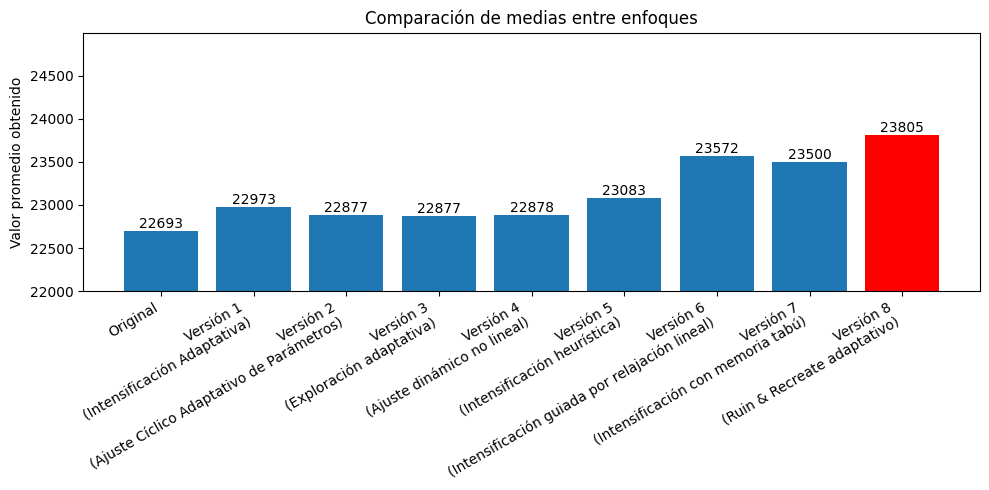

In [ ]:
import matplotlib.pyplot as plt
#con enfoque antiguo
# Medias ya calculadas
medias = [
    media_original,
    media_version1,
    media_version2,
    media_version3,
    media_version4,
    media_version5,
    media_version6,
    media_version7,
    media_version8
]

labels = [
    "Original",
    "Versión 1\n(Intensificación Adaptativa)",
    "Versión 2\n(Ajuste Cíclico Adaptativo de Parámetros)",
    "Versión 3\n(Exploración adaptativa)",
    "Versión 4\n(Ajuste dinámico no lineal)",
    "Versión 5\n(Intensificación heurística)",
    "Versión 6\n(Intensificación guiada por relajación lineal)",
    "Versión 7\n(Intensificación con memoria tabú)",
    "Versión 8\n(Ruin & Recreate adaptativo)"
]
colors = ["tab:blue"] * 8 + ["red"]

plt.figure(figsize=(10, 5))
plt.bar(labels, medias, color=colors)
plt.ylabel("Valor promedio obtenido")
plt.title("Comparación de medias entre enfoques")
plt.xticks(rotation=30, ha="right")
plt.ylim(bottom=22000)

plt.xticks(rotation=30, ha="right")

for i, v in enumerate(medias):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()


###Desviacion estandar

In [ ]:
resultados = [
    results_original,
    results_version1,
    results_version2,
    results_version3,
    results_version4,
    results_version5,
    results_version6,
    results_version7,
    results_version8
]

for label, data in zip(labels, resultados):
    std = np.std(data)
    print(f"{label}: desviación estándar = {std:.4f}")

Original: desviación estándar = 214.9926
Versión 1
(Intensificación Adaptativa): desviación estándar = 177.1814
Versión 2
(Ajuste Cíclico Adaptativo de Parámetros): desviación estándar = 238.3326
Versión 3
(Exploración adaptativa): desviación estándar = 222.7054
Versión 4
(Ajuste dinámico no lineal): desviación estándar = 205.0700
Versión 5
(Intensificación heurística): desviación estándar = 222.0361
Versión 6
(Intensificación guiada por relajación lineal): desviación estándar = 255.8785
Versión 7
(Intensificación con memoria tabú): desviación estándar = 284.5420
Versión 8
(Ruin & Recreate adaptativo): desviación estándar = 225.4084


/tmp/ipykernel_388/1680895124.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


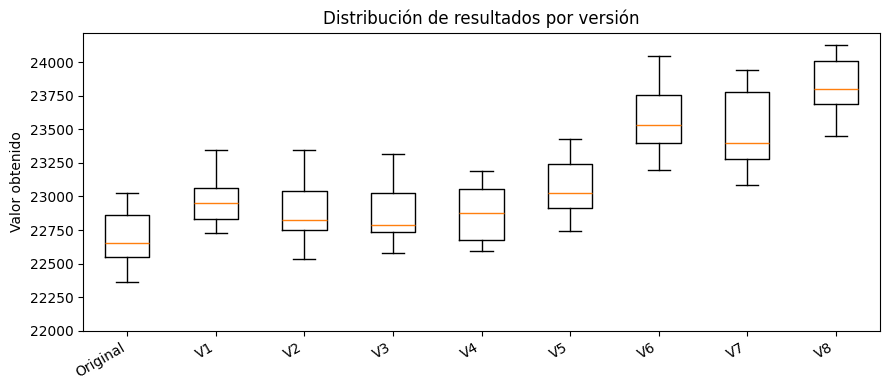

In [ ]:
plt.figure(figsize=(9,4))
plt.boxplot(
    [
        results_original,
        results_version1,
        results_version2,
        results_version3,
        results_version4,
        results_version5,
        results_version6,
        results_version7,
        results_version8
    ],
    labels= [
    "Original",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
    "V7",
    "V8"
],
    showfliers=True
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Valor obtenido")
plt.title("Distribución de resultados por versión")
plt.ylim(bottom=22000)
plt.tight_layout()
plt.show()


###Wilcoxon

In [ ]:
from scipy.stats import wilcoxon

resultados = {
    "Original": results_original,
    "V1": results_version1,
    "V2": results_version2,
    "V3": results_version3,
    "V4": results_version4,
    "V5": results_version5,
    "V6": results_version6,
    "V7": results_version7,
    "V8": results_version8
}

for k, data in resultados.items():
    if k != "Original":
        stat, p = wilcoxon(data, results_original, alternative="greater")
        print(f"{k} vs Original -> p-value = {p:.5f}")

V1 vs Original -> p-value = 0.01855
V2 vs Original -> p-value = 0.06543
V3 vs Original -> p-value = 0.03223
V4 vs Original -> p-value = 0.02441
V5 vs Original -> p-value = 0.00195
V6 vs Original -> p-value = 0.00098
V7 vs Original -> p-value = 0.00098
V8 vs Original -> p-value = 0.00098
